In [1]:
%load_ext autoreload
%autoreload 2

In [310]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import decorate, underride, configure_plot_style, AIBM_COLORS

configure_plot_style()

In [561]:
def load_and_inventory(filename):
    df = pd.read_csv(filename).query('Year >= 2000 and CountryCode == "COUNTRY"')
    print(df.shape)

    try:
        print(df['IndicatorCode'].unique())
        print(df['IndicatorName'].unique())
    except KeyError:
        pass

    sexes = df['Sex'].unique()
    print(sexes)
    print(df['Comments'].unique())
    years = df['Year'].unique()
    print(years)
    print(df['Country'].unique())
    
    return df, years

In [562]:
def summarize_gap(df, col, sexes, year):
    df_gap = compute_gender_gap(df, col, sexes)
    
    # TODO: get the most recent for each country
    df_recent = df_gap.query('Year == @year').set_index('Country')
    
    if len(sexes) > 1:
        cols = [f'{col}_{sex}' for sex in sexes]
        high = df_recent[cols].max().max()
        domain = [0, high]
        scatter_plot(df_recent, cols, domain)
        decorate(xlabel=f'{col}, Male', 
                 ylabel=f'{col}, Female', title=f'All Countries, {year}')
    
    return df_gap, df_recent

## WHO HALE data

Downloaded using the GHO OData API (who_data.py)

https://www.who.int/data/gho/info/gho-odata-api

In [632]:
filename = '../data/who_hale_data.csv'
hale = load_and_inventory(filename)

(12210, 9)
['SEX_BTSX' 'SEX_FMLE' 'SEX_MLE']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019 2020 2021]
['AFG' 'AGO' 'ALB' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL'
 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA' 'BRB'
 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG'
 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DNK' 'DOM' 'DZA'
 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA' 'FSM' 'GAB' 'GBR'
 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM' 'GUY' 'HND' 'HRV'
 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR'
 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KOR' 'KWT' 'LAO' 'LBN' 'LBR' 'LBY'
 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MDA' 'MDG' 'MDV' 'MEX' 'MKD'
 'MLI' 'MLT' 'MMR' 'MNE' 'MNG' 'MOZ' 'MRT' 'MUS' 'MWI' 'MYS' 'NAM' 'NER'
 'NGA' 'NIC' 'NLD' 'NOR' 'NPL' 'NZL' 'OMN' 'PAK' 'PAN' 'PER' 'PHL' 'PNG'
 'POL' 'PRI' 'PRK' 'PRT' 'PRY' 'P

In [633]:
from functools import reduce

def compute_gender_gap(df, value_col, sexes):
    """
    Return a DataFrame with separate columns for each sex and a gap column,
    handling cases where one or more sexes are missing.

    Parameters
    ----------
    df : pandas.DataFrame
        Must include 'Country', 'Year', 'Sex', and the specified value_col.
    value_col : str
        Name of the column containing the numeric value to compare between sexes.
    sexes : list of str
        List of values in the 'Sex' column, e.g. ['SEX_MLE', 'SEX_FMLE'].
        The first two entries are used to compute the gap (second - first).

    Returns
    -------
    df_by_sex : pandas.DataFrame
        Contains columns for each available sex and a gap column (second - first)
        if both sexes are present.
    """
    cols = ['Country', 'Year', value_col]
    dfs = []

    # Build a renamed DataFrame for each sex, only if it exists
    for sex in sexes:
        temp = df[df['Sex'] == sex]
        if not temp.empty:
            temp = temp[cols].copy()
            temp = temp.rename(columns={value_col: f"{value_col}_{sex}"})
            dfs.append(temp)

    # If no data at all, return empty DataFrame
    if not dfs:
        return pd.DataFrame(columns=['Country', 'Year'])

    # Merge all available sexes
    df_by_sex = reduce(lambda left, right: left.merge(right, on=['Country', 'Year'], how='outer'), dfs)

    # Compute the gap only if both sexes are available
    if len(sexes) >= 2:
        col1 = f"{value_col}_{sexes[0]}"
        col2 = f"{value_col}_{sexes[1]}"
        if col1 in df_by_sex.columns and col2 in df_by_sex.columns:
            df_by_sex[f"{value_col}_Gap"] = df_by_sex[col2] - df_by_sex[col1]

    return df_by_sex


In [634]:
sexes = ['SEX_MLE', 'SEX_FMLE']
hale_gap = compute_gender_gap(who_hale, 'HALE_Years', sexes)

In [635]:
hale_gap.head()

,Country,Year,HALE_Years_SEX_MLE,HALE_Years_SEX_FMLE,HALE_Years_Gap
0,AFG,2000,45.943669,46.154851,0.211182
1,AFG,2001,45.989073,46.284875,0.295802
2,AFG,2002,47.407615,46.994510,-0.413105
3,AFG,2003,48.291904,47.702906,-0.588998
4,AFG,2004,48.637754,48.050686,-0.587069


In [636]:
hale_gap['HALE_Years_SEX_MLE'].isna().sum()

0

In [637]:
hale_gap['HALE_Years_SEX_FMLE'].isna().sum()

0

In [638]:
recent = hale_gap.query('Year == 2021').set_index('Country')
recent.head()

,Year,HALE_Years_SEX_MLE,HALE_Years_SEX_FMLE,HALE_Years_Gap
Country,,,,
AFG,2021,49.646948,51.312914,1.665966
AGO,2021,52.803224,54.731134,1.927909
ALB,2021,65.735885,67.758414,2.022528
ARE,2021,67.376838,66.808010,-0.568828
ARG,2021,63.436500,66.150735,2.714235


In [639]:
def scatter_plot(df, cols, domain, **options):
    plt.plot(df[cols[0]], df[cols[1]], '.', color=AIBM_COLORS['crimson'])
    plt.plot(domain, domain, color='gray', alpha=0.5)
    
    underride(options, aspect='equal')
    decorate(**options)

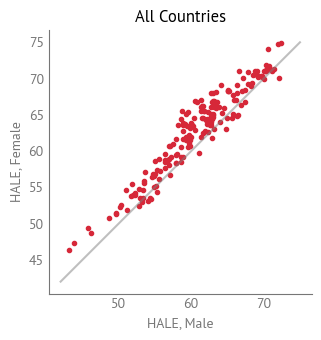

In [640]:
cols = ['HALE_Years_SEX_MLE', 'HALE_Years_SEX_FMLE']
domain = [42, 75]
scatter_plot(recent, cols, domain)
decorate(xlabel='HALE, Male', ylabel='HALE, Female', title='All Countries')

In [674]:
from utils import oecd_codes

def get_oecd(df):
    # TODO: Warn if any are missing
    return df.loc[df.index.intersection(oecd_codes)]


df_oecd = get_oecd(recent)
df_oecd

,Year,HALE_Years_SEX_MLE,HALE_Years_SEX_FMLE,HALE_Years_Gap
Country,,,,
AUS,2021,70.129739,71.083329,0.953589
AUT,2021,69.052840,70.492301,1.439461
BEL,2021,69.277436,70.274321,0.996885
CAN,2021,68.929934,70.636013,1.706078
CHE,2021,70.909329,71.347458,0.438128
CHL,2021,67.053862,68.273016,1.219154
COL,2021,63.290852,66.819771,3.528919
CRI,2021,66.276979,69.052011,2.775032
CZE,2021,65.046933,68.323581,3.276648


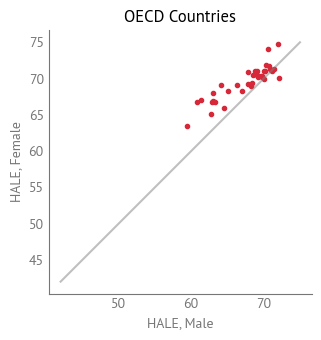

In [642]:
scatter_plot(df_oecd, cols, domain)
decorate(xlabel='HALE, Male', ylabel='HALE, Female', title='OECD Countries')

In [643]:
from empiricaldist import Cdf

def plot_cdfs(df, label='', **options):
    cols = [col for col in df.columns if col.endswith('ale')]
    for col in cols:
        vals = df[col].dropna()
        if vals.count() == 0:
            break
        cdf = Cdf.from_seq(df[col])
        cdf.plot(label=f'{col} {label}', **options)
        underride(options)

In [644]:
def plot_distributions(recent, **options):
    plot_cdfs(recent, label='All countries')
    plot_cdfs(get_oecd(recent), label='OECD')
    
    underride(options, ylabel='CDF')
    decorate(**options)

## Smoking

M_Est_smk_curr_std

In [645]:
filename = '../data/who_smoking_data.csv'
smoking, years = load_and_inventory(filename)

(4950, 11)
['M_Est_smk_curr_std']
['Age-standardized current tobacco smoking prevalence']
['Both sexes' 'Female' 'Male']
[nan 'The most recent survey was conducted in 2019. This is a projection.'
 'The most recent survey was conducted in 2017-18. This is a projection.'
 'The most recent survey was conducted in 2018. This is a projection.'
 'The most recent survey was conducted in 2016. This is a projection.'
 'The most recent survey was conducted in 2020-21. This is a projection.'
 'The most recent survey was conducted in 2020. This is a projection.'
 'The most recent survey was conducted in 2016-17. This is a projection.'
 'The most recent survey was conducted in 2021. This is a projection.'
 'The most recent survey was conducted in 2013. This is a projection.'
 'The most recent survey was conducted in 2017-19. This is a projection.'
 'The most recent survey was conducted in 2011-12. This is a projection.'
 'The most recent survey was conducted in 2022. This is a projection.'
 'The mo

In [646]:
smoking.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,SmokingPrevalence,SmokingPrevalence_Low,SmokingPrevalence_High,Comments,DataSource
0,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2000,Both sexes,22.5,10.5,34.4,NaN,NaN
1,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2005,Both sexes,17.9,9.6,26.3,NaN,NaN
2,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2007,Both sexes,16.3,9.4,23.3,NaN,NaN
3,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2010,Both sexes,14.5,9.6,19.4,NaN,NaN
4,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2015,Both sexes,11.8,8.0,15.6,NaN,NaN


In [647]:
smoking['Projection'] = smoking['Comments'].notna()
smoking['Projection'].value_counts()

Projection
False    2763
True     2187
Name: count, dtype: int64

In [648]:
sexes = ['Male', 'Female']
smoking_gap = compute_gender_gap(smoking, 'SmokingPrevalence', sexes)
smoking_gap

,Country,Year,SmokingPrevalence_Male,SmokingPrevalence_Female,SmokingPrevalence_Gap
0,AFG,2000,34.4,10.5,-23.9
1,AFG,2005,28.7,7.1,-21.6
2,AFG,2007,26.6,6.1,-20.5
3,AFG,2010,24.1,4.8,-19.3
4,AFG,2015,20.3,3.3,-17.0
...,...,...,...,...,...
1645,ZWE,2020,21.3,0.9,-20.4
1646,ZWE,2021,20.7,0.8,-19.9
1647,ZWE,2022,20.2,0.8,-19.4
1648,ZWE,2025,18.6,0.7,-17.9


In [649]:
smoking_recent = smoking_gap.query('Year == 2021').set_index('Country')
smoking_recent.head()

,Year,SmokingPrevalence_Male,SmokingPrevalence_Female,SmokingPrevalence_Gap
Country,,,,
AFG,2021,16.6,2.1,-14.5
ALB,2021,38.5,6.2,-32.3
AND,2021,35.0,37.3,2.3
ARE,2021,15.9,2.6,-13.3
ARG,2021,28.9,19.4,-9.5


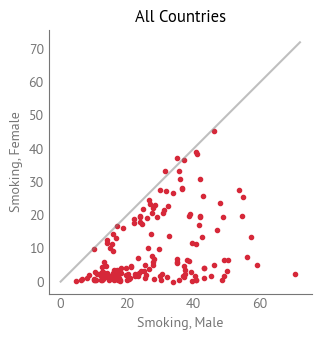

In [650]:
cols = ['SmokingPrevalence_Male', 'SmokingPrevalence_Female']
domain = [0, 72]
scatter_plot(smoking_recent, cols, domain)
decorate(xlabel='Smoking, Male', ylabel='Smoking, Female', title='All Countries')

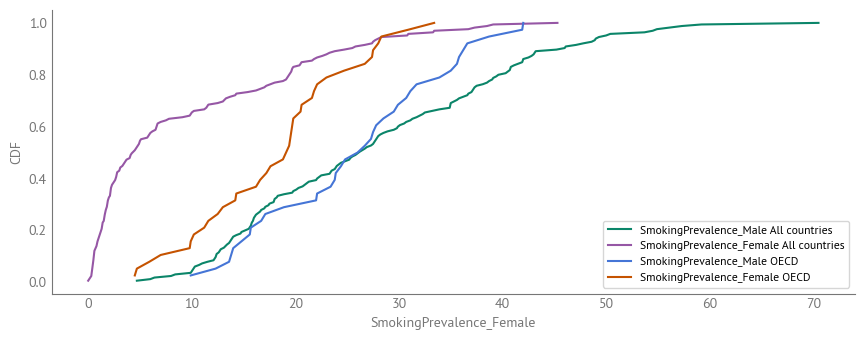

In [651]:
plot_distributions(smoking_recent)

## Suicide

In [652]:
filename = '../data/who_suicide_rates.csv'
suicide, years = load_and_inventory(filename)

(12210, 11)
['MH_12']
['Age-standardized suicide rates (per 100 000 population)']
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019 2020 2021]
['AFG' 'AGO' 'ALB' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL'
 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA' 'BRB'
 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG'
 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DNK' 'DOM' 'DZA'
 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA' 'FSM' 'GAB' 'GBR'
 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM' 'GUY' 'HND' 'HRV'
 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR'
 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KOR' 'KWT' 'LAO' 'LBN' 'LBR' 'LBY'
 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MDA' 'MDG' 'MDV' 'MEX' 'MKD'
 'MLI' 'MLT' 'MMR' 'MNE' 'MNG' 'MOZ' 'MRT' 'MUS' 'MWI' 'MYS' 'NAM' 'NER'
 'NGA' 'NIC' 'NLD' 'NOR' 'NPL' 'NZL' '

In [653]:
suicide.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,SuicideRate,SuicideRate_Low,SuicideRate_High,Comments,DataSource
0,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2000,Both sexes,7.185717,3.764944,12.084243,NaN,NaN
1,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2001,Both sexes,7.270323,3.817979,12.215665,NaN,NaN
2,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2002,Both sexes,7.112670,3.821785,11.814730,NaN,NaN
3,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2003,Both sexes,7.043811,3.856506,12.002093,NaN,NaN
4,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2004,Both sexes,7.025987,3.889151,12.129586,NaN,NaN


In [654]:
sexes = ['Male', 'Female']
suicide_gap = compute_gender_gap(suicide, 'SuicideRate', sexes)
suicide_gap

,Country,Year,SuicideRate_Male,SuicideRate_Female,SuicideRate_Gap
0,AFG,2000,9.609622,4.934659,-4.674962
1,AFG,2001,9.712121,4.996167,-4.715954
2,AFG,2002,9.626535,4.757103,-4.869432
3,AFG,2003,9.501130,4.732772,-4.768358
4,AFG,2004,9.332455,4.849891,-4.482564
...,...,...,...,...,...
4065,ZWE,2017,36.020550,14.132308,-21.888242
4066,ZWE,2018,37.575817,14.861527,-22.714290
4067,ZWE,2019,35.922467,14.441421,-21.481046
4068,ZWE,2020,36.060025,14.211690,-21.848335


In [655]:
suicide_recent = suicide_gap.query('Year == 2021').set_index('Country')
suicide_recent.head()

,Year,SuicideRate_Male,SuicideRate_Female,SuicideRate_Gap
Country,,,,
AFG,2021,6.973242,3.700843,-3.272399
AGO,2021,24.434650,6.343335,-18.091315
ALB,2021,2.560051,1.742901,-0.817149
ARE,2021,2.334462,0.531895,-1.802568
ARG,2021,12.175256,3.363413,-8.811843


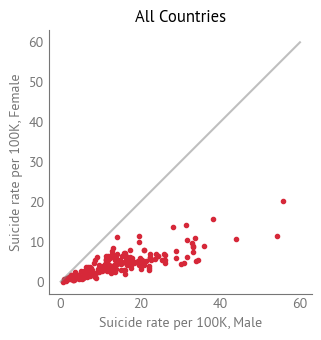

In [656]:
cols = ['SuicideRate_Male', 'SuicideRate_Female']
domain = [0, 60]
scatter_plot(suicide_recent, cols, domain)
decorate(xlabel='Suicide rate per 100K, Male', 
         ylabel='Suicide rate per 100K, Female', title='All Countries')

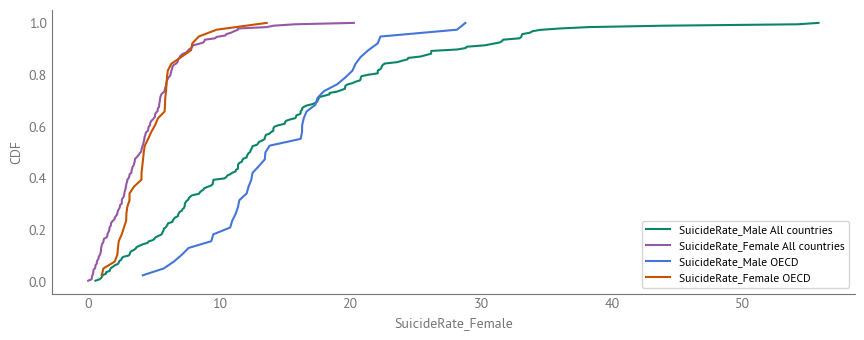

In [657]:
plot_distributions(suicide_recent)

## Alcohol

In [658]:
filename = '../data/who_alcohol_death_rates.csv'
alcohol, years = load_and_inventory(filename)

(540, 11)
['SA_0000001832']
['Alcohol-attributable all-cause deaths per 100,000, age standardized']
['Both sexes' 'Female' 'Male']
[nan]
[2019]
['AFG' 'AGO' 'ALB' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL'
 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA' 'BRB'
 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG'
 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DNK' 'DOM' 'DZA'
 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA' 'FSM' 'GAB' 'GBR'
 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM' 'GUY' 'HND' 'HRV'
 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR'
 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KOR' 'KWT' 'LAO' 'LBN' 'LBR' 'LBY'
 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MDA' 'MDG' 'MDV' 'MEX' 'MKD'
 'MLI' 'MLT' 'MMR' 'MNG' 'MOZ' 'MRT' 'MUS' 'MWI' 'MYS' 'NAM' 'NER' 'NGA'
 'NIC' 'NLD' 'NOR' 'NPL' 'NZL' 'OMN' 'PAK' 'PAN' 'PER' 'PHL' 'PNG' 'POL'
 'PRK' 'PRT' 'PRY' 'QAT' 'ROU' 'RUS' 'RWA' 'SAU' 'SDN

In [659]:
alcohol.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,AlcoholDeathRate,AlcoholDeathRate_Low,AlcoholDeathRate_High,Comments,DataSource
0,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AFG,COUNTRY,2019,Both sexes,4.949863,4.002665,6.983689,NaN,NaN
1,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AFG,COUNTRY,2019,Female,4.002300,2.527392,6.215428,NaN,NaN
2,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AFG,COUNTRY,2019,Male,5.914343,4.479561,9.296961,NaN,NaN
3,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AGO,COUNTRY,2019,Both sexes,88.707178,63.949144,114.463780,NaN,NaN
4,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AGO,COUNTRY,2019,Female,34.885563,26.543712,47.578170,NaN,NaN


In [660]:
sexes = ['Male', 'Female']
alcohol_gap = compute_gender_gap(alcohol, 'AlcoholDeathRate', sexes)
alcohol_gap

,Country,Year,AlcoholDeathRate_Male,AlcoholDeathRate_Female,AlcoholDeathRate_Gap
0,AFG,2019,5.914343,4.002300,-1.912043
1,AGO,2019,150.328156,34.885563,-115.442593
2,ALB,2019,38.540438,18.234894,-20.305544
3,ARE,2019,9.966941,4.735602,-5.231339
4,ARG,2019,48.356525,7.704571,-40.651954
...,...,...,...,...,...
175,WSM,2019,39.526011,12.871891,-26.654120
176,YEM,2019,4.693835,1.837837,-2.855998
177,ZAF,2019,118.703742,24.171142,-94.532600
178,ZMB,2019,126.121084,23.402148,-102.718936


In [661]:
alcohol_recent = alcohol_gap.query('Year == 2019').set_index('Country')
alcohol_recent.head()

,Year,AlcoholDeathRate_Male,AlcoholDeathRate_Female,AlcoholDeathRate_Gap
Country,,,,
AFG,2019,5.914343,4.002300,-1.912043
AGO,2019,150.328156,34.885563,-115.442593
ALB,2019,38.540438,18.234894,-20.305544
ARE,2019,9.966941,4.735602,-5.231339
ARG,2019,48.356525,7.704571,-40.651954


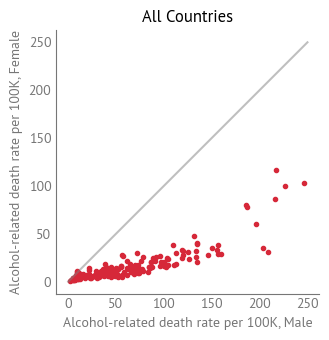

In [662]:
cols = ['AlcoholDeathRate_Male', 'AlcoholDeathRate_Female']
domain = [0, 250]
scatter_plot(alcohol_recent, cols, domain)
decorate(xlabel='Alcohol-related death rate per 100K, Male', 
         ylabel='Alcohol-related death rate per 100K, Female', title='All Countries')

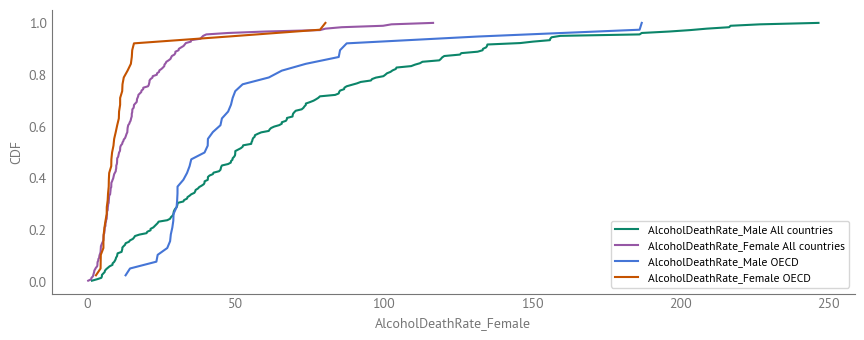

In [663]:
plot_distributions(alcohol_recent)

## Poison

In [664]:
filename = '../data/who_poisoning_rates.csv'
poison, years = load_and_inventory(filename)

(12210, 11)
['SDGPOISON']
['Mortality rate attributed to unintentional poisoning (per 100 000 population)']
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019 2020 2021]
['AFG' 'AGO' 'ALB' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL'
 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA' 'BRB'
 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG'
 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DNK' 'DOM' 'DZA'
 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA' 'FSM' 'GAB' 'GBR'
 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM' 'GUY' 'HND' 'HRV'
 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR'
 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KOR' 'KWT' 'LAO' 'LBN' 'LBR' 'LBY'
 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MDA' 'MDG' 'MDV' 'MEX' 'MKD'
 'MLI' 'MLT' 'MMR' 'MNE' 'MNG' 'MOZ' 'MRT' 'MUS' 'MWI' 'MYS' 'NAM' 'NER'
 'NGA' 'NIC'

In [665]:
poison.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,PoisoningRate,PoisoningRate_Low,PoisoningRate_High,Comments,DataSource
0,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2000,Both sexes,3.272761,1.091069,6.816218,NaN,NaN
1,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2001,Both sexes,3.351724,1.157869,6.926548,NaN,NaN
2,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2002,Both sexes,3.038659,0.946774,6.704357,NaN,NaN
3,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2003,Both sexes,3.689834,1.521052,7.401055,NaN,NaN
4,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2004,Both sexes,3.681742,1.573983,7.347575,NaN,NaN


In [666]:
sexes = ['Male', 'Female']
poison_gap = compute_gender_gap(poison, 'PoisoningRate', sexes)
poison_gap

,Country,Year,PoisoningRate_Male,PoisoningRate_Female,PoisoningRate_Gap
0,AFG,2000,4.080808,2.459967,-1.620841
1,AFG,2001,4.168267,2.529098,-1.639169
2,AFG,2002,3.868734,2.201071,-1.667663
3,AFG,2003,4.554284,2.816185,-1.738099
4,AFG,2004,4.458072,2.895969,-1.562103
...,...,...,...,...,...
4065,ZWE,2017,4.180130,2.326128,-1.854002
4066,ZWE,2018,4.508153,2.623988,-1.884165
4067,ZWE,2019,4.045519,2.363694,-1.681825
4068,ZWE,2020,4.066497,2.371240,-1.695257


In [667]:
poison_recent = poison_gap.query('Year == 2019').set_index('Country')
poison_recent.head()

,Year,PoisoningRate_Male,PoisoningRate_Female,PoisoningRate_Gap
Country,,,,
AFG,2019,3.297636,2.466282,-0.831353
AGO,2019,1.228625,0.838043,-0.390582
ALB,2019,0.346017,0.242977,-0.103040
ARE,2019,0.281525,0.056339,-0.225186
ARG,2019,0.537595,0.291770,-0.245825


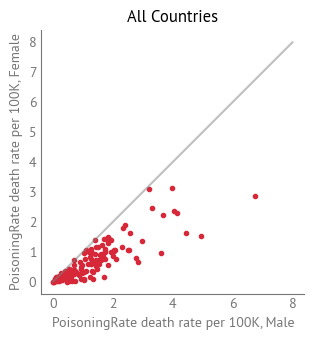

In [668]:
cols = ['PoisoningRate_Male', 'PoisoningRate_Female']
domain = [0, 8]
scatter_plot(poison_recent, cols, domain)
decorate(xlabel='PoisoningRate death rate per 100K, Male', 
         ylabel='PoisoningRate death rate per 100K, Female', title='All Countries')

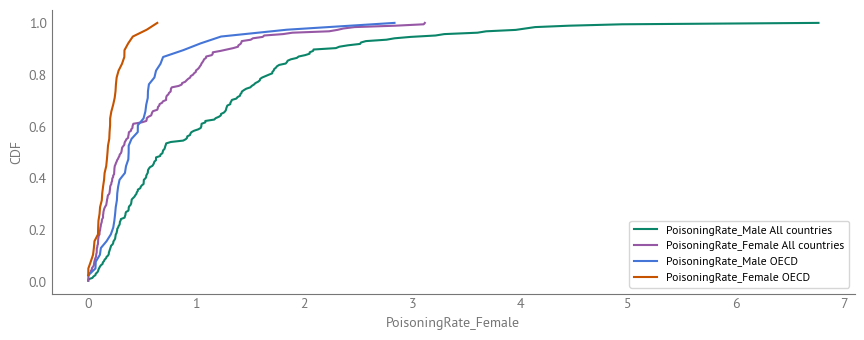

In [669]:
plot_distributions(poison_recent)

## Traffic

In [670]:
filename = '../data/who_road_traffic_death_rates.csv'
traffic, years = load_and_inventory(filename)

(1080, 11)
['SA_0000001459']
['Road traffic crash deaths, age-standardized death rates (15+), per 100,000 population']
['Both sexes' 'Female' 'Male']
[nan]
[2019]
['AFG' 'AGO' 'ALB' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL'
 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA' 'BRB'
 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG'
 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DNK' 'DOM' 'DZA'
 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA' 'FSM' 'GAB' 'GBR'
 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM' 'GUY' 'HND' 'HRV'
 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR'
 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KOR' 'KWT' 'LAO' 'LBN' 'LBR' 'LBY'
 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MDA' 'MDG' 'MDV' 'MEX' 'MKD'
 'MLI' 'MLT' 'MMR' 'MNG' 'MOZ' 'MRT' 'MUS' 'MWI' 'MYS' 'NAM' 'NER' 'NGA'
 'NIC' 'NLD' 'NOR' 'NPL' 'NZL' 'OMN' 'PAK' 'PAN' 'PER' 'PHL' 'PNG' 'POL'
 'PRK' 'PRT' 'PRY' 'QAT' 'ROU' 'RU

In [671]:
traffic.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,RoadTrafficDeathRate,RoadTrafficDeathRate_Low,RoadTrafficDeathRate_High,Comments,DataSource
0,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AFG,COUNTRY,2019,Both sexes,25.062360,NaN,NaN,NaN,NaN
1,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AFG,COUNTRY,2019,Both sexes,19.806936,NaN,NaN,NaN,NaN
2,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AFG,COUNTRY,2019,Female,8.323253,NaN,NaN,NaN,NaN
3,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AFG,COUNTRY,2019,Female,10.041166,NaN,NaN,NaN,NaN
4,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AFG,COUNTRY,2019,Male,39.476597,NaN,NaN,NaN,NaN


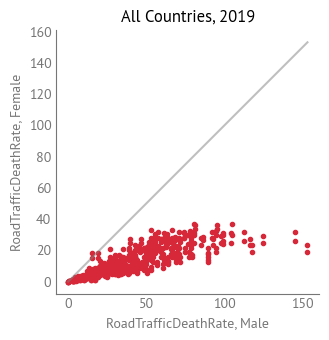

In [672]:
col = 'RoadTrafficDeathRate'
sexes = ['Male', 'Female']
year = years[-1]
traffic_gap, traffic_recent = summarize_gap(traffic, col, sexes, year)

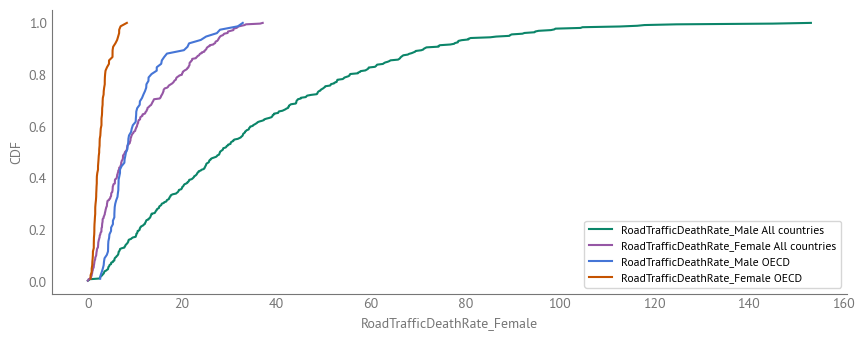

In [673]:
plot_distributions(traffic_recent)

## Maternal mortality

In [617]:
filename = '../data/who_maternal_mortality_ratio.csv'
maternal, years = load_and_inventory(filename)

(4680, 11)
['MDG_0000000026']
['Maternal mortality ratio (per 100 000 live births)']
['Female']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023]
['AFG' 'AGO' 'ALB' 'AND' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI'
 'BEL' 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA'
 'BRB' 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD'
 'COG' 'COK' 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DMA'
 'DNK' 'DOM' 'DZA' 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA'
 'FSM' 'GAB' 'GBR' 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM'
 'GUY' 'HND' 'HRV' 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR'
 'ITA' 'JAM' 'JOR' 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KNA' 'KOR' 'KWT'
 'LAO' 'LBN' 'LBR' 'LBY' 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MCO'
 'MDA' 'MDG' 'MDV' 'MEX' 'MHL' 'MKD' 'MLI' 'MLT' 'MMR' 'MNE' 'MNG' 'MOZ'
 'MRT' 'MUS' 'MWI' 'MYS' 'NAM' 'NER' 'NGA' 'N

In [618]:
maternal.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,MaternalMortalityRatio,MaternalMortalityRatio_Low,MaternalMortalityRatio_High,Comments,DataSource
0,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2000,Female,1371.645908,937.495878,1828.321863,NaN,NaN
1,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2001,Female,1310.954923,906.872935,1734.166876,NaN,NaN
2,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2002,Female,1262.516681,884.408915,1652.739115,NaN,NaN
3,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2003,Female,1201.381450,857.173518,1567.186347,NaN,NaN
4,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2004,Female,1166.469374,849.256289,1515.271527,NaN,NaN


In [619]:
col = 'MaternalMortalityRatio'
df_gap = compute_gender_gap(maternal, col, sexes=['Female'])
df_gap

,Country,Year,MaternalMortalityRatio_Female
0,AFG,2000,1371.645908
1,AFG,2001,1310.954923
2,AFG,2002,1262.516681
3,AFG,2003,1201.381450
4,AFG,2004,1166.469374
...,...,...,...
4843,ZWE,2019,387.600430
4844,ZWE,2020,379.971381
4845,ZWE,2021,446.416849
4846,ZWE,2022,367.806587


In [620]:
col = 'MaternalMortalityRatio'
year = years[-1]
maternal_gap, maternal_recent = summarize_gap(maternal, col, sexes=['Female'], year=year)

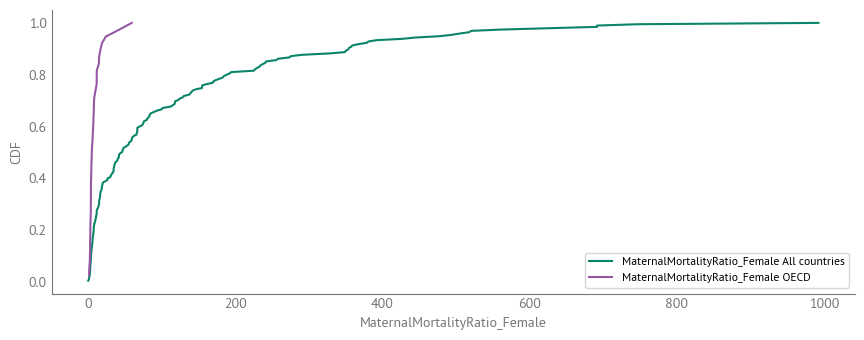

In [621]:
plot_distributions(maternal_recent)

## Homicide

In [622]:
filename = '../data/who_homicide_rates.csv'
homicide, years = load_and_inventory(filename)

(12210, 11)
['VIOLENCE_HOMICIDERATE']
['Estimates of rates of homicides per 100 000 population']
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019 2020 2021]
['AFG' 'AGO' 'ALB' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL'
 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA' 'BRB'
 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG'
 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DNK' 'DOM' 'DZA'
 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA' 'FSM' 'GAB' 'GBR'
 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM' 'GUY' 'HND' 'HRV'
 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR'
 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KOR' 'KWT' 'LAO' 'LBN' 'LBR' 'LBY'
 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MDA' 'MDG' 'MDV' 'MEX' 'MKD'
 'MLI' 'MLT' 'MMR' 'MNE' 'MNG' 'MOZ' 'MRT' 'MUS' 'MWI' 'MYS' 'NAM' 'NER'
 'NGA' 'NIC' 'NLD' 'NOR

In [623]:
homicide.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,HomicideRate,HomicideRate_Low,HomicideRate_High,Comments,DataSource
0,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2000,Both sexes,10.433863,5.581236,16.844870,NaN,NaN
1,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2001,Both sexes,10.617865,5.678589,17.162430,NaN,NaN
2,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2002,Both sexes,10.953708,6.568415,16.902796,NaN,NaN
3,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2003,Both sexes,10.781847,6.539156,16.757218,NaN,NaN
4,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2004,Both sexes,10.135798,5.742813,16.420052,NaN,NaN


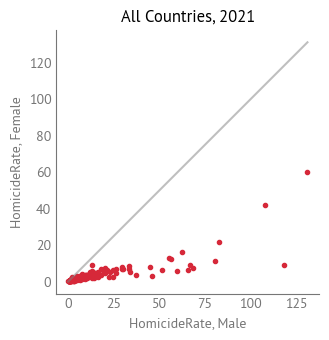

In [624]:
col = 'HomicideRate'
year = years[-1]
homicide_gap, homicide_recent = summarize_gap(homicide, col, sexes, year)

## Intimate Partner Violence

In [675]:
filename = '../data/who_ipv_prevalence.csv'
ipv, years = load_and_inventory(filename)

(558, 11)
['SDGIPV']
['Proportion of ever-partnered women and girls aged 15-49 years subjected to physical and/or sexual violence by a current or former intimate partner in the previous 12 months']
['Female']
['DHS '
 'calculated by FRA based on available country data from the 2012 FRA Violence against women: an EU-wide Survey  Women aged 18-74; definition of physical and sexual violence differs from the standard'
 'Violence against Women Survey 2015 '
 'Calculated by UNFPA based on available country data from the Violence against Women Survey 2015 UNECE methodology; women aged 15+'
 'PAHO 2018 publication Intimate Partner Violence against Women in the Americas: calculated by PAHO based on available country data from the Encuesta de Prevalencia y Caracteristicas de la Violencia contra las Mujeres 2016 ~ENDIREH methodology; women aged 15+; definition of sexual violence differs from the standard'
 'MICS ' 'DHS Currently married'
 'DHS Refers to currently married girls and women'
 'The Co

In [676]:
ipv.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,IPVPrevalence,IPVPrevalence_Low,IPVPrevalence_High,Comments,DataSource
18,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,49.1,NaN,NaN,DHS,NaN
19,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,45.2,NaN,NaN,DHS,NaN
20,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,51.9,NaN,NaN,DHS,NaN
21,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,49.3,NaN,NaN,DHS,NaN
22,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,48.6,NaN,NaN,DHS,NaN


In [682]:
ipv['Year'].value_counts()

Year
2016    98
2012    92
2014    91
2015    61
2017    55
2013    49
2006    29
2007    17
2009    17
2010    14
2011    14
2008    11
2005     9
2000     1
Name: count, dtype: int64

In [685]:
col = 'IPVPrevalence'
year = 2017
ipv_gap, ipv_recent = summarize_gap(ipv, col, sexes=['Female'], year=year)
ipv_recent

,Year,IPVPrevalence_Female
Country,,
BDI,2017,22.50
BDI,2017,29.00
BDI,2017,34.40
BDI,2017,37.80
BDI,2017,27.90
BDI,2017,28.60
BDI,2017,21.90
BDI,2017,26.50
HTI,2017,14.90


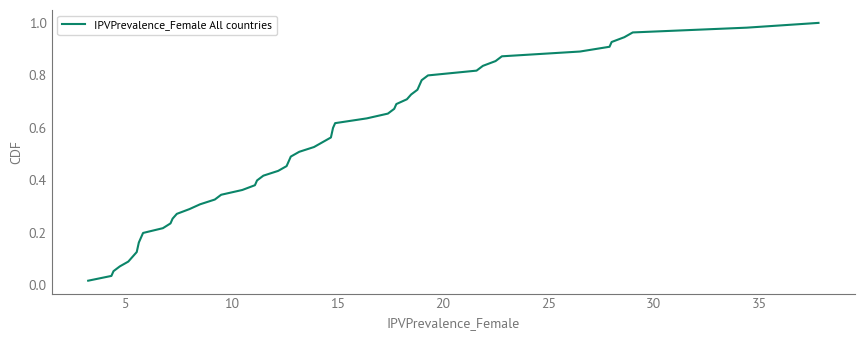

In [686]:
plot_distributions(ipv_recent)

## Under five mortality rate

In [281]:
filename = '../data/who_u5mr.csv'
u5mr, years = load_and_inventory(filename)

['MDG_0000000007']
['Under-five mortality rate (probability of dying by age 5 per 1000 live births)']
['Both sexes' 'Female' 'Male']
[nan
 'Some UN IGME indicators are calculated using population and live birth numbers from the World Population Prospects: The 2024 revision (WPP). The WPP numbers for Cyprus refer to the entire country. However, the underlying data used to calculate mortality rates estimates, provided by the Health Monitoring Unit of the Cyprus Ministry of Health, cover only the government-controlled areas, whereas according to Eurostat, the number of live births in 2023 was 10,295 (https://ec.europa.eu/eurostat/databrowser/view/tps00204/), the population on 1 January 2023 was 920,701 (https://ec.europa.eu/eurostat/databrowser/view/tps00001/), the population under 5 was 49,326,  adolescent population was 99,207 and the number of women of reproductive age was 235,268 (https://doi.org/10.2908/DEMO_PJAN).'
 'The UN IGME estimates are not the official statistics of India. Th

In [282]:
u5mr.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,U5MR,U5MR_Low,U5MR_High,Comments,DataSource
0,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,131.657158,122.050144,142.254414,NaN,NaN
1,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,146.404320,129.690344,164.793287,NaN,NaN
2,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,116.604951,101.901270,133.012767,NaN,NaN
3,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,139.669993,126.880951,153.782482,NaN,NaN
4,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,92.831046,79.709380,107.613673,NaN,NaN


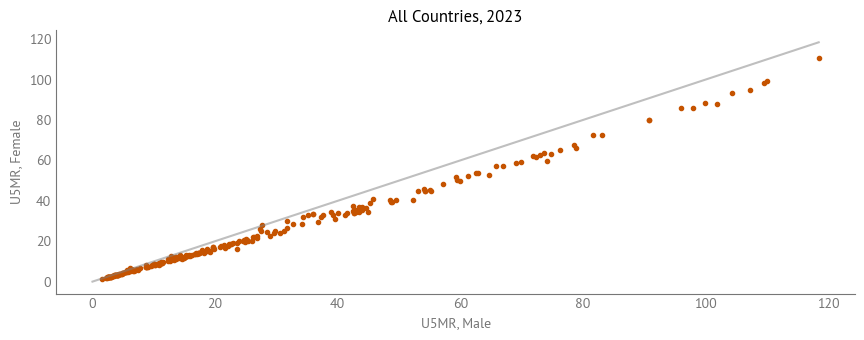

In [283]:
col = 'U5MR'
year = years[-1]
u5mr_gap, u5mr_recent = summarize_gap(u5mr, col, sexes, year)

## Cardio

In [287]:
filename = '../data/who_cardiovascular_death_rates.csv'

cardio, years = load_and_inventory(filename)

['SA_0000001444']
[nan]
['Both sexes' 'Female' 'Male']
[nan]
[2004]
['AFG' 'AGO' 'ALB' 'AND' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI'
 'BEL' 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA'
 'BRB' 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD'
 'COG' 'COK' 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DMA'
 'DNK' 'DOM' 'DZA' 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA'
 'FSM' 'GAB' 'GBR' 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM'
 'GUY' 'HND' 'HRV' 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR'
 'ITA' 'JAM' 'JOR' 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KNA' 'KOR' 'KWT'
 'LAO' 'LBN' 'LBR' 'LBY' 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MCO'
 'MDA' 'MDG' 'MDV' 'MEX' 'MHL' 'MKD' 'MLI' 'MLT' 'MMR' 'MNG' 'MOZ' 'MRT'
 'MUS' 'MWI' 'MYS' 'NAM' 'NER' 'NGA' 'NIC' 'NIU' 'NLD' 'NOR' 'NPL' 'NRU'
 'NZL' 'OMN' 'PAK' 'PAN' 'PER' 'PHL' 'PLW' 'PNG' 'POL' 'PRK' 'PRT' 'PRY'
 'QAT' 'ROU' 'RUS' 'RWA' 'SAU' 'SDN' 'SEN' 'SGP' 'SLB' '

In [288]:
cardio.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,DeathRate,DeathRate_Low,DeathRate_High,Comments,DataSource
0,SA_0000001444,NaN,AFG,COUNTRY,2004,Both sexes,366.9,NaN,NaN,NaN,NaN
1,SA_0000001444,NaN,AFG,COUNTRY,2004,Female,282.9,NaN,NaN,NaN,NaN
2,SA_0000001444,NaN,AFG,COUNTRY,2004,Male,447.4,NaN,NaN,NaN,NaN
3,SA_0000001444,NaN,AGO,COUNTRY,2004,Both sexes,142.4,NaN,NaN,NaN,NaN
4,SA_0000001444,NaN,AGO,COUNTRY,2004,Female,111.0,NaN,NaN,NaN,NaN


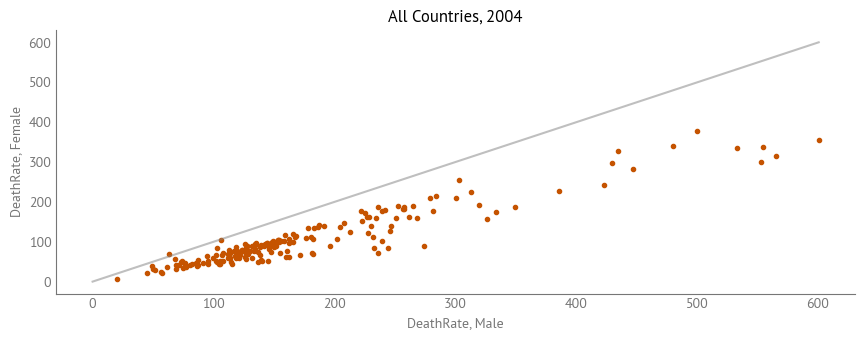

In [301]:
col = 'DeathRate'
year = years[-1]
cardio_gap, cardio_recent = summarize_gap(cardio, col, sexes, year)

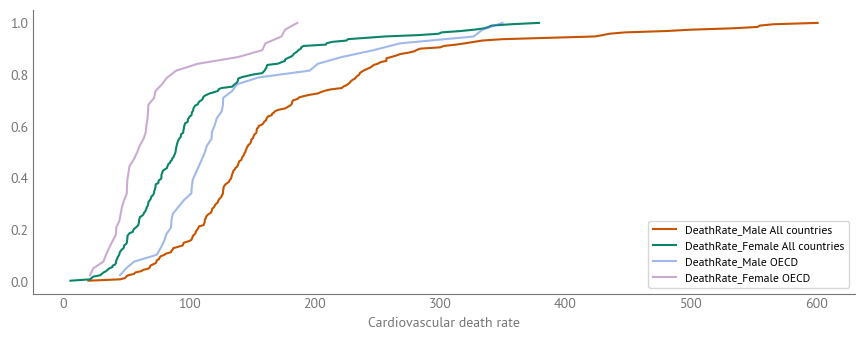

In [303]:
plot_distributions(cardio_recent)
decorate(xlabel='Cardiovascular death rate', label='CDF')

## Diabetes

In [304]:
filename = '../data/who_diabetes_death_rates.csv'

diabetes, years = load_and_inventory(filename)

['SA_0000001440']
['Age-standardized death rates, diabetes mellitus, per 100,000']
['Both sexes' 'Female' 'Male']
[nan]
[2004]
['AFG' 'AGO' 'ALB' 'AND' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI'
 'BEL' 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA'
 'BRB' 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD'
 'COG' 'COK' 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DMA'
 'DNK' 'DOM' 'DZA' 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA'
 'FSM' 'GAB' 'GBR' 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM'
 'GUY' 'HND' 'HRV' 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR'
 'ITA' 'JAM' 'JOR' 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KNA' 'KOR' 'KWT'
 'LAO' 'LBN' 'LBR' 'LBY' 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MCO'
 'MDA' 'MDG' 'MDV' 'MEX' 'MHL' 'MKD' 'MLI' 'MLT' 'MMR' 'MNG' 'MOZ' 'MRT'
 'MUS' 'MWI' 'MYS' 'NAM' 'NER' 'NGA' 'NIC' 'NIU' 'NLD' 'NOR' 'NPL' 'NRU'
 'NZL' 'OMN' 'PAK' 'PAN' 'PER' 'PHL' 'PLW' 'PNG' 'POL' 'PRK' 'PRT' 'PR

In [305]:
diabetes.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,DiabetesDeathRate,DiabetesDeathRate_Low,DiabetesDeathRate_High,Comments,DataSource
0,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AFG,COUNTRY,2004,Both sexes,29.3,NaN,NaN,NaN,NaN
1,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AFG,COUNTRY,2004,Female,30.9,NaN,NaN,NaN,NaN
2,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AFG,COUNTRY,2004,Male,27.5,NaN,NaN,NaN,NaN
3,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AGO,COUNTRY,2004,Both sexes,67.6,NaN,NaN,NaN,NaN
4,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AGO,COUNTRY,2004,Female,74.2,NaN,NaN,NaN,NaN


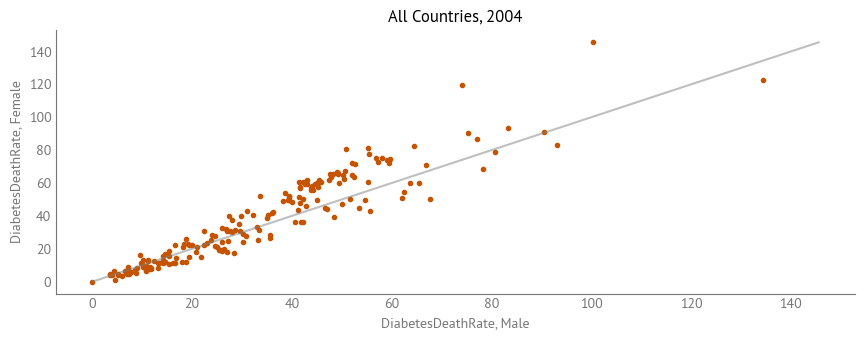

In [306]:
col = 'DiabetesDeathRate'
year = years[-1]
diabetes_gap, diabetes_recent = summarize_gap(diabetes, col, sexes, year)

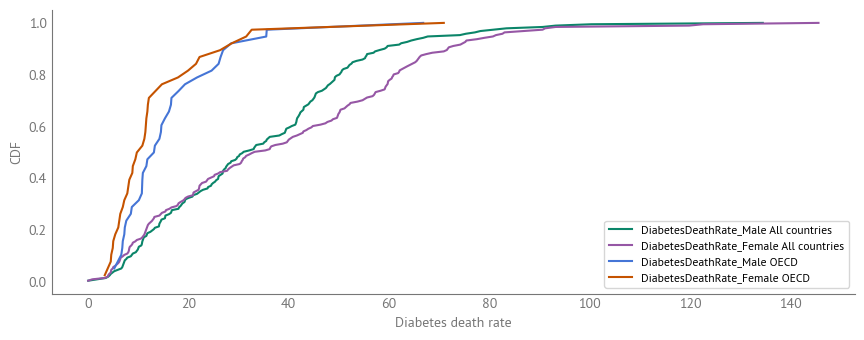

In [319]:
plot_distributions(diabetes_recent, xlabel='Diabetes death rate')